# GFDL-ESM4

In [2]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

In [3]:
import xarray as xr
from pathlib import Path
import numpy as np

# =========================
# 1. Settings
# =========================

DATA_DIR = Path(
    "/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/ISIMIP3b data/ELM-ECA/GFDL-ESM4"
)

OUT_DIR = Path("processed_data_isimip")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMPACT_MODEL = "ELM-ECA"
CLIMATE_DRIVER = "GFDL-ESM4"

VARIABLE_TOAD = "cveg_total"

SCENARIOS = ["ssp126", "ssp370", "ssp585"]

# Amazon rough bounding box
LAT_MIN, LAT_MAX = -25, 10
LON_MIN, LON_MAX = -85, -30

In [4]:
# =========================
# 2. Helper functions
# =========================

def find_file(pattern):
    matches = sorted(DATA_DIR.glob(pattern))

    if len(matches) == 0:
        print("DATA_DIR:", DATA_DIR)
        print("Pattern:", pattern)
        print("Available files:")
        for f in DATA_DIR.glob("*.nc"):
            print(" -", f.name)

        raise FileNotFoundError(f"No file found for pattern: {pattern}")

    if len(matches) > 1:
        print("[Warning] Multiple files found. Using first one:")
        for m in matches:
            print(" -", m.name)

    return matches[0]


def standardize_lat_lon(ds):
    rename_dict = {}

    if "latitude" in ds.coords:
        rename_dict["latitude"] = "lat"
    if "longitude" in ds.coords:
        rename_dict["longitude"] = "lon"

    if rename_dict:
        ds = ds.rename(rename_dict)

    # Convert 0..360 to -180..180
    if ds["lon"].max() > 180:
        ds = ds.assign_coords(
            lon=((ds["lon"] + 180) % 360) - 180
        )
        ds = ds.sortby("lon")

    ds = ds.sortby("lat")

    return ds


def select_amazon_bbox(ds):
    ds = standardize_lat_lon(ds)

    return ds.sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX),
    )


def detect_cveg_variable(ds):
    """
    Detect internal cveg variable name.
    Filename says cveg-total, but inside NetCDF it may be cveg, cveg-total, etc.
    """

    candidates = [
        "cveg",
        "cveg-total",
        "cveg_total",
    ]

    for var in candidates:
        if var in ds.data_vars:
            return var

    cveg_like = [
        v for v in ds.data_vars
        if "cveg" in v.lower()
    ]

    if len(cveg_like) == 1:
        return cveg_like[0]

    print("Available data variables:")
    print(list(ds.data_vars))

    raise ValueError("Could not uniquely detect cveg variable.")


def monthly_stock_to_annual_mean(da):
    """
    cveg is a stock variable, so use annual mean, not annual sum.
    """

    da_annual = da.resample(time="1YS").mean(skipna=True)

    return da_annual


def convert_time_to_year(ds):
    years = ds["time"].dt.year.values

    ds = ds.assign_coords(time=years)
    ds["time"].attrs["long_name"] = "calendar year"
    ds["time"].attrs["units"] = "year"

    return ds

# =========================
# 3. Load historical file
# =========================

historical_path = find_file(
    "*historical_histsoc_default_cveg-total_global_monthly_1850_2014.nc"
)

print("Historical file:")
print(historical_path.name)

ds_hist = xr.open_dataset(historical_path, decode_times=True)
ds_hist = standardize_lat_lon(ds_hist)

RAW_VAR = detect_cveg_variable(ds_hist)

print("Detected variable:", RAW_VAR)

# =========================
# 4. Process each SSP
# =========================

for scenario in SCENARIOS:
    future_path = find_file(
        f"*{scenario}_2015soc-from-histsoc_default_cveg-total_global_monthly_2015_2100.nc"
    )

    print("\nProcessing scenario:", scenario)
    print("Future file:", future_path.name)

    ds_fut = xr.open_dataset(future_path, decode_times=True)
    ds_fut = standardize_lat_lon(ds_fut)

    # Extract variable
    da_hist = ds_hist[RAW_VAR]
    da_fut = ds_fut[RAW_VAR]

    # Combine monthly historical + future
    da_monthly = xr.concat(
        [da_hist, da_fut],
        dim="time",
    )

    da_monthly = da_monthly.sortby("time")

    # Convert monthly stock to annual mean
    da_annual = monthly_stock_to_annual_mean(da_monthly)

    # Rename for TOAD
    da_annual = da_annual.rename(VARIABLE_TOAD)

    # Select Amazon bbox
    ds_amazon = select_amazon_bbox(da_annual.to_dataset())
    ds_amazon = convert_time_to_year(ds_amazon)

    # Remove duplicated years if any
    _, unique_idx = np.unique(
        ds_amazon["time"].values,
        return_index=True,
    )
    ds_amazon = ds_amazon.isel(time=np.sort(unique_idx))

    # Metadata
    ds_amazon.attrs["source"] = "ISIMIP3b OutputData Biomes"
    ds_amazon.attrs["impact_model"] = IMPACT_MODEL
    ds_amazon.attrs["climate_driver"] = CLIMATE_DRIVER
    ds_amazon.attrs["scenario"] = scenario
    ds_amazon.attrs["soc_scenario"] = "historical_histsoc + future_2015soc-from-histsoc"
    ds_amazon.attrs["variable_original"] = RAW_VAR
    ds_amazon.attrs["variable_to_toad"] = VARIABLE_TOAD
    ds_amazon.attrs["region"] = "Amazon rough bounding box"
    ds_amazon.attrs["time_axis"] = "calendar year"
    ds_amazon.attrs["monthly_to_annual"] = "annual mean because cveg is a stock variable"

    ds_amazon[VARIABLE_TOAD].attrs = da_annual.attrs.copy()
    ds_amazon[VARIABLE_TOAD].attrs["long_name"] = "Total vegetation carbon"
    ds_amazon[VARIABLE_TOAD].attrs["processing"] = "Monthly cveg-total converted to annual mean"

    # Save
    out_path = (
        OUT_DIR
        / f"TOAD_ISIMIP3b_{IMPACT_MODEL}_{CLIMATE_DRIVER}_{scenario}_{VARIABLE_TOAD}_Amazon_annual_1850_2100.nc"
    )

    ds_amazon.to_netcdf(out_path)

    print("[Saved]", out_path)
    print(ds_amazon)

Historical file:
elm-eca_gfdl-esm4_w5e5_historical_histsoc_default_cveg-total_global_monthly_1850_2014.nc
Detected variable: cveg-total

Processing scenario: ssp126
Future file: elm-eca_gfdl-esm4_w5e5_ssp126_2015soc-from-histsoc_default_cveg-total_global_monthly_2015_2100.nc


KeyboardInterrupt: 

In [25]:
import sys
import os

# Get the parent directory of the 'test' folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# Target the 'toad-main' directory which contains the actual 'toad' package folder
toad_main_path = os.path.join(parent_dir, "toad-main")

# Add the 'toad-main' path to the system path
if toad_main_path not in sys.path:
    sys.path.append(toad_main_path)

# Now Python can locate the 'toad' folder inside 'toad-main'
from toad import TOAD

VARIABLE = "cveg_total"
SCENARIO = "ssp585"

file_path = (
    f"processed_data_isimip/"
    f"TOAD_ISIMIP3b_ELM-ECA_GFDL-ESM4_{SCENARIO}_"
    f"cveg_total_Amazon_annual_1850_2100.nc"
)

ds = xr.open_dataset(file_path)

ds_future = ds.sel(time=slice(2015, 2100))

td = TOAD(ds_future)

In [26]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var=VARIABLE, method=ASDETECT())
# ~12 seconds

Shift detection (7700 grid cells in 32 blocks):   0%|          | 0/32 [00:00<?, ?it/s]

INFO: New shifts variable cveg_total_dts: min/mean/max=-0.979/-0.013/1.000 using 4511 grid cells. Skipped 41.4% grid cells: 3099 NaN, 90 constant.


In [13]:
### Including DBSCAN
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN


class SpaceTimeDBSCAN(ClusterMixin, BaseEstimator):
    """DBSCAN with separate eps for spatial and temporal dimensions.

    Args:
        spatial_eps (float, optional): Epsilon for spatial dimensions in km, if using lat/lon data, else in units of the spatial dimensions
        temporal_eps (float, optional): Epsilon for the temporal dimension in units of the time variable
        min_samples (int): Minimum number of samples in a neighborhood for a point to be
            considered a core point (DBSCAN min_samples).
    """

    skip_time_scaling = True  # Protocol: TOAD skips its time scaling when True

    def __init__(
        self,
        spatial_eps,
        temporal_eps,
        min_samples=5,
    ):
        self.spatial_eps = spatial_eps
        self.temporal_eps = temporal_eps
        self.min_samples = min_samples

    def fit_predict(self, X: np.ndarray, y=None, **kwargs):
        assert y is not None, "y must be provided"

        # Scale time and space independently to control their relative importance
        X_scaled = X.copy()

        # Scale spatial dimensions by spatial_eps
        X_scaled[:, 1:] = X[:, 1:] / self.spatial_eps

        # Scale temporal dimension by temporal_eps
        X_scaled[:, 0] = X[:, 0] / self.temporal_eps

        # Now run DBSCAN with eps=1 (since we pre-scaled)
        dbscan = DBSCAN(eps=1.0, min_samples=self.min_samples, metric="euclidean")
        labels = dbscan.fit_predict(X_scaled)

        return labels

INFO: optimizing 500 trials with params: {'spatial_eps': (100.0, 1000.0), 'temporal_eps': (1, 20), 'min_samples': (20, 60)}


  0%|          | 0/500 [00:00<?, ?it/s]

INFO: Ran 500 trials in 14.67 seconds. Best (#26): score 0.8480, params {'spatial_eps': 624.6524923905718, 'temporal_eps': 5, 'min_samples': 25}. 
INFO: New cluster variable cveg_total_dts_cluster: Identified 1 cluster in 486 pts; Left 92.8% as noise (451 pts).


(<Figure size 640x480 with 2 Axes>,
 {'map': <GeoAxes: xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>,
  'timeseries': [<Axes: title={'center': 'clusters in Total vegetation carbon [kg\nm-2]'}, xlabel='calendar year [year]'>]})

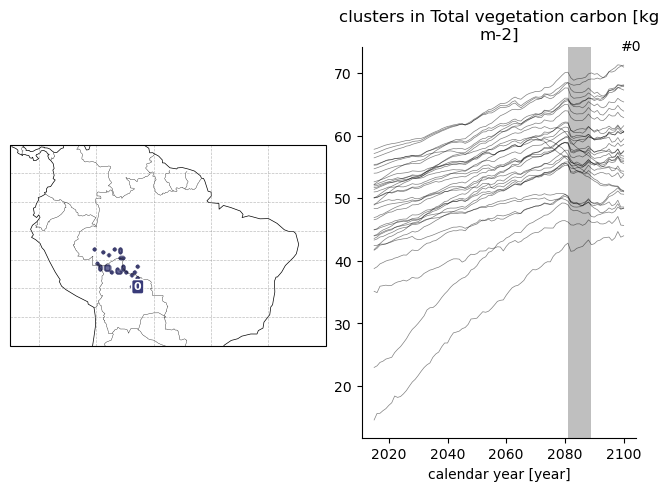

Exception ignored in: <function ResourceTracker.__del__ at 0x104909bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104aadbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107e55bc0>
Traceback (most recent call last

In [ ]:
td.compute_clusters(
    var=VARIABLE,
    method=SpaceTimeDBSCAN,
    shift_direction="negative",
    shift_selection="local",

    optimize=True,
    optimize_params={
        "spatial_eps": (100.0, 1000.0),   # km
        "temporal_eps": (1, 20),       # years
        "min_samples": (20, 60),            # integer
    },

    optimize_objective="combined_spatial_nonlinearity",
    optimize_direction="maximize",
    optimize_n_trials=500,
    overwrite=True,
)

# plot the latest cluster variable
# td.plot.overview(td.cluster_vars[-1], normalize="max_each"); normalisation the y-axis 
td.plot.overview(td.cluster_vars[-1])

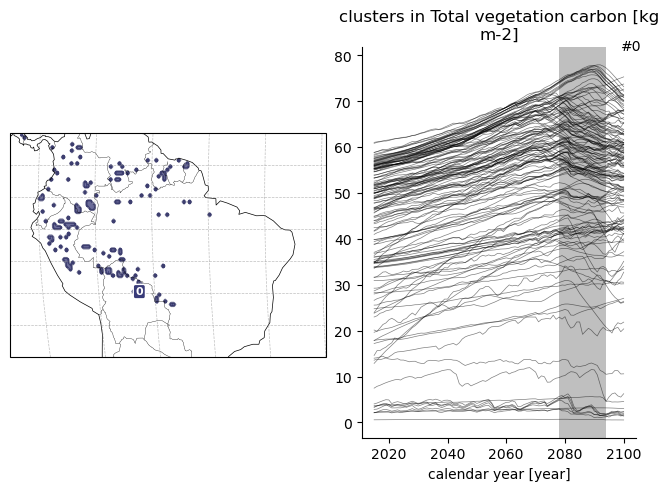

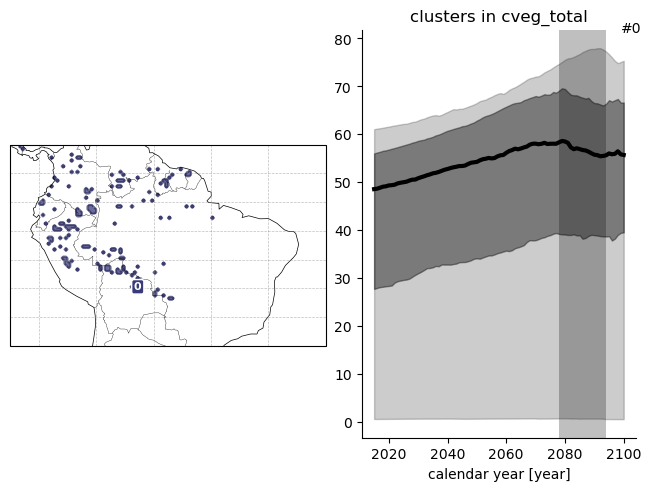

In [28]:
td.plot.overview(map_style={"projection": "global"});
td.plot.overview(mode="aggregated");

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for cveg_total'}, xlabel='lon', ylabel='lat'>)

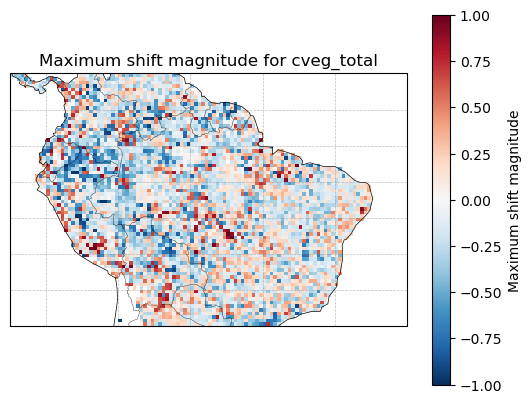

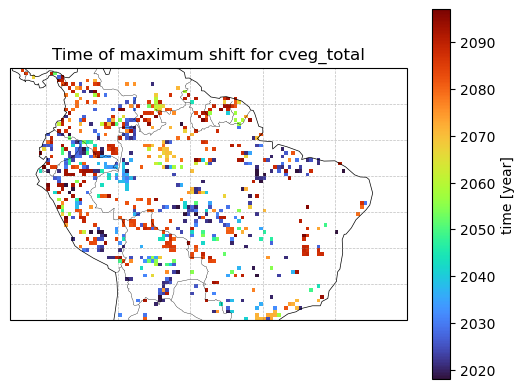

In [29]:
td.plot.max_shift_map()
td.plot.time_of_max_shift_map()

First 20 years mean: nan
Last 20 years mean: 24.64931297302246
Change: nan


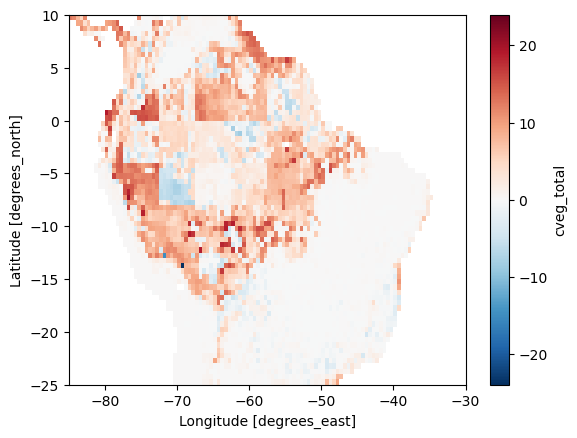

In [37]:
da = td.data["cveg_total"]

# 1. Amazon 평균 시계열
area_mean = da.mean(dim=["lat", "lon"], skipna=True)
area_mean.plot()

print("First 20 years mean:", float(area_mean.sel(time=slice(1850, 1870)).mean()))
print("Last 20 years mean:", float(area_mean.sel(time=slice(2080, 2100)).mean()))
print("Change:", float(area_mean.sel(time=slice(2080, 2100)).mean() - area_mean.sel(time=slice(1850, 1870)).mean()))

# 2. 연도별 감소 비율
diff = da.diff("time")
negative_fraction = (diff < 0).mean(dim=["lat", "lon"], skipna=True)

negative_fraction.plot()

early = da.sel(time=slice(1950, 2050)).mean("time")
late = da.sel(time=slice(2050, 2100)).mean("time")

change = late - early
change.plot()